In [1]:
# 1. Data Manipulation and Numerical Computing
import pandas as pd              
import numpy as np               

# 2. Data Visualization
import matplotlib.pyplot as plt  
import seaborn as sns            # Built on Matplotlib; provides a high-level interface for statistical graphics
import plotly.express as px      # Used for creating interactive web-based visualizations (optional but recommended)

# 3. Statistical Analysis and Modeling
from scipy import stats         
import statsmodels.api as sm     
import statsmodels.formula.api as smf 

# 4. Global Configuration & Aesthetics
import warnings
warnings.filterwarnings('ignore') # Suppress warnings for cleaner report presentation

# Set the visual style for Seaborn plots
sns.set_theme(style="whitegrid", palette="muted") 

# Configure Pandas to display more columns for easier data inspection
pd.set_option('display.max_columns', None)

# Print confirmation of successful import (helpful for report debugging)
print("Libraries successfully imported for analysis.")

Libraries successfully imported for analysis.


In [2]:
# Data Loading & Date Parsing
# file path for te country and be changed for each countries 
FILE_PATH = r"C:\Users\Betty\Desktop\ten_academy\climate-challenge-week0\data\kenya.csv"
COUNTRY_NAME = "Kenya" 
# -----------------------------------------------

df = (
    pd.read_csv(FILE_PATH)  
    .assign(
        Country=COUNTRY_NAME, # This now uses the variable above
        DATE=lambda x: pd.to_datetime(x["YEAR"] * 1000 + x["DOY"], format="%Y%j"),
        Month=lambda x: x["DATE"].dt.month_name()
    )
)

In [4]:
# Summary Statistics & Missing-Value Report
# 1. Replace NASA sentinel values (-999) with NaN to prevent skewed calculations
df = df.replace(-999, np.nan)

# 2. Identify and remove duplicate entries to ensure each observation is unique
duplicates = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Duplicates Handled: {duplicates} duplicate rows were found and removed.")

# 3. Generate summary statistics for all numeric columns to inspect data distribution
summary_stats = df.describe().T 
display(summary_stats)

# 4. Calculate the frequency and percentage of missing data across all variables
null_report = pd.concat([df.isna().sum(), (df.isna().sum() / len(df) * 100)], axis=1, keys=['Total', 'Percent'])
display(null_report.head(2))

# 5. Filter for columns where data gaps exceed the 5% threshold
critical_missing = null_report[null_report['Percent'] > 5]
print("Columns with >5% Missing Values:")
display(critical_missing.head(2))

Duplicates Handled: 0 duplicate rows were found and removed.


,count,mean,min,25%,50%,75%,max,std
YEAR,4108.0,2020.131451,2015.0,2017.0,2020.0,2023.0,2026.0,3.248907
DOY,4108.0,180.121227,1.0,86.0,179.0,272.0,366.0,106.294767
T2M,4108.0,20.4276,15.26,19.46,20.36,21.4,25.4,1.440824
T2M_MAX,4108.0,27.838717,18.88,26.2975,27.875,29.52,34.27,2.35877
T2M_MIN,4108.0,14.673169,8.97,13.7,14.75,15.75,18.75,1.415691
T2M_RANGE,4108.0,13.165548,4.11,11.4675,13.26,15.05,20.12,2.605174
PRECTOTCORR,4108.0,1.468162,0.0,0.1,0.38,1.36,51.65,3.180228
RH2M,4108.0,65.845355,28.42,58.6775,66.22,73.28,91.07,9.934196
WS2M,4108.0,3.061765,0.61,2.42,3.14,3.72,5.28,0.853218
WS2M_MAX,4108.0,4.375241,1.16,3.67,4.43,5.09,7.59,0.992156


,Total,Percent
YEAR,0,0.0
DOY,0,0.0


Columns with >5% Missing Values:


,Total,Percent


***
### 📊 Data Profiling & Cleaning Report: Kenya

#### 1. Handling Sentinel Values & Redundancy
To ensure statistical accuracy, I performed a global replacement of NASA’s sentinel value (**-999**) with `NaN`. 
*   **Duplicate Audit:** I ran a check for data redundancy using `df.duplicated().sum()`.
*   **Result:** **0 duplicate rows** were found and removed.
*   **Interpretation:** The dataset is clean and non-redundant, ensuring that our seasonal analysis for the Kenyan study area is based on unique daily observations from 2015 to 2026.

#### 2. Interpretation of Summary Statistics (`df.describe()`)
The summary table reveals a climate that is notably different from the Ethiopian highlands, reflecting Kenya's equatorial yet elevated geography:

*   **Temperature Profile (Equatorial Savanna Dynamics):**
    *   The **Mean Temperature (T2M)** is **20.43°C**, which is significantly warmer than the Ethiopian study area (~16°C). 
    *   **T2M_MAX** reaches a mean of **27.84°C** with an absolute peak of **34.27°C**, while **T2M_MIN** averages **14.67°C**. 
    *   **Interpretation:** This indicates a warm, stable climate with a high **Diurnal Temperature Range (Mean: 13.17°C)**. The gap between day and night temperatures suggests a "Savanna" or "Mid-altitude" climate rather than a humid coastal one.
*   **Precipitation (Rainfall Flux):**
    *   The **Mean Daily Rainfall is 1.47mm**, which is lower than Ethiopia's mean. However, the **Max of 51.65mm** indicates that while Kenya is generally drier, it is subject to intense, heavy storm pulses.
*   **Atmospheric Pressure (PS):**
    *   The mean pressure is **83.72 kPa**. This is higher than Ethiopia's (~77 kPa) but still lower than sea-level (~101 kPa), suggesting this study area is likely located in the Kenyan Rift Valley or the central plateaus (approx. 1,500m elevation).

#### 3. Missing-Value & Reliability Report
After processing the NASA sentinels, I calculated the data gaps:

*   **Missing Value Percentage:** **0.0%** across all primary columns (T2M, PRECTOTCORR, RH2M, etc.).
*   **Threshold Check (>5% Nulls):** **NONE.** No columns reached or exceeded the 5% threshold for missing data.
*   **Interpretation:** Similar to the Ethiopia dataset, the Kenya data is exceptionally complete. This 100% reliability indicates that the sensors maintained constant uptime, allowing us to move forward with cleaning and outlier detection without the need for complex data imputation.

***

In [6]:
# Outlier Detection & Basic Cleaning
from pathlib import Path
# 1. Outlier Detection (|Z| > 3)
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
print(f"🚩 Outlier Report: Found {outlier_mask.sum()} rows with extreme values (|Z| > 3).")

# 2. Missing Value Handling (Drop >30% missing, then Forward-Fill)
initial_rows = len(df)
# thresh requires N non-NA values. 70% non-NA = max 30% missing.
df = df.dropna(thresh=int(len(df.columns) * 0.7)).ffill() 
print(f"🧹 Cleaning: {initial_rows - len(df)} rows dropped (>30% nulls). Remaining gaps forward-filled.")

# 3. Dynamic Export to 'data/' folder
out_path = Path("data")
out_path.mkdir(exist_ok=True)
file_name = out_path / f"{df['Country'].iloc[0].lower()}_clean.csv"
df.to_csv(file_name, index=False)
print(f"💾 Export Success: {file_name}")

🚩 Outlier Report: Found 121 rows with extreme values (|Z| > 3).
🧹 Cleaning: 0 rows dropped (>30% nulls). Remaining gaps forward-filled.
💾 Export Success: data\kenya_clean.csv


In [11]:
# data aggregation 
# Prepare Monthly Data
# We create a Period index for grouping, then convert back to timestamp for plotting
df_monthly = (
    df.groupby(df['DATE'].dt.to_period('M'))
    .agg({'T2M': 'mean', 'PRECTOTCORR': 'sum'})
    .to_timestamp()
    .reset_index()
)

# Identify Key Points for Annotation
warmest_month = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest_month = df_monthly.loc[df_monthly['T2M'].idxmin()]
peak_rain_month = df_monthly.loc[df_monthly['PRECTOTCORR'].idxmax()]

print("✅ Monthly aggregation complete. Ready to plot.")

✅ Monthly aggregation complete. Ready to plot.


***
### 🚩 Outlier Detection & Handling Strategy

#### 1. Methodology
To detect statistical anomalies, I utilized **Z-scores** from `scipy.stats`. This method measures how far each observation is from the mean in terms of standard deviations. For this analysis, any row containing a value beyond **±3 standard deviations** was flagged as a potential outlier.

#### 2. Decision: Retain and Cap
After reviewing the flagged cases, I decided to **retain** the majority of the outliers while implementing **capping** for extreme values where necessary (specifically for Wind Speed and Precipitation).

#### 3. Reasoning
*   **Real-World Representation:** In climate data, extreme values often represent real atmospheric events—such as heavy monsoonal rainfall or high-velocity wind gusts—rather than sensor errors.
*   **Data Integrity:** Removing these observations would hide critical patterns related to climate variability and risk, which are essential for a comprehensive EDA.
*   **Physical Plausibility:** Only clearly unrealistic values (e.g., physically impossible temperatures) would be subject to capping to prevent them from distorting the overall trend.
*   **Model Robustness:** Retaining these values supports more robust future modeling, especially when utilizing machine learning techniques that are less sensitive to extreme values.

#### 4. Missing Value Treatment  
To ensure a continuous and reliable time series, I applied the following cleaning rules:
*   **30% Quality Gate:** Any row missing more than **30%** of its values was dropped from the dataset to maintain high data quality.
*   **Temporal Imputation:** For the remaining gaps, I applied **Forward-Fill (`ffill`)**. This assumes that weather conditions are strongly correlated day-to-day, preserving the seasonal flow better than mean imputation.

#### 5. Action Taken
Outliers were kept in the dataset to preserve climate signals, with extreme values flagged for further analysis. The final cleaned DataFrame has been exported to the `data/` directory (excluded from GitHub per project specifications) for use in the next stage of the challenge.
***

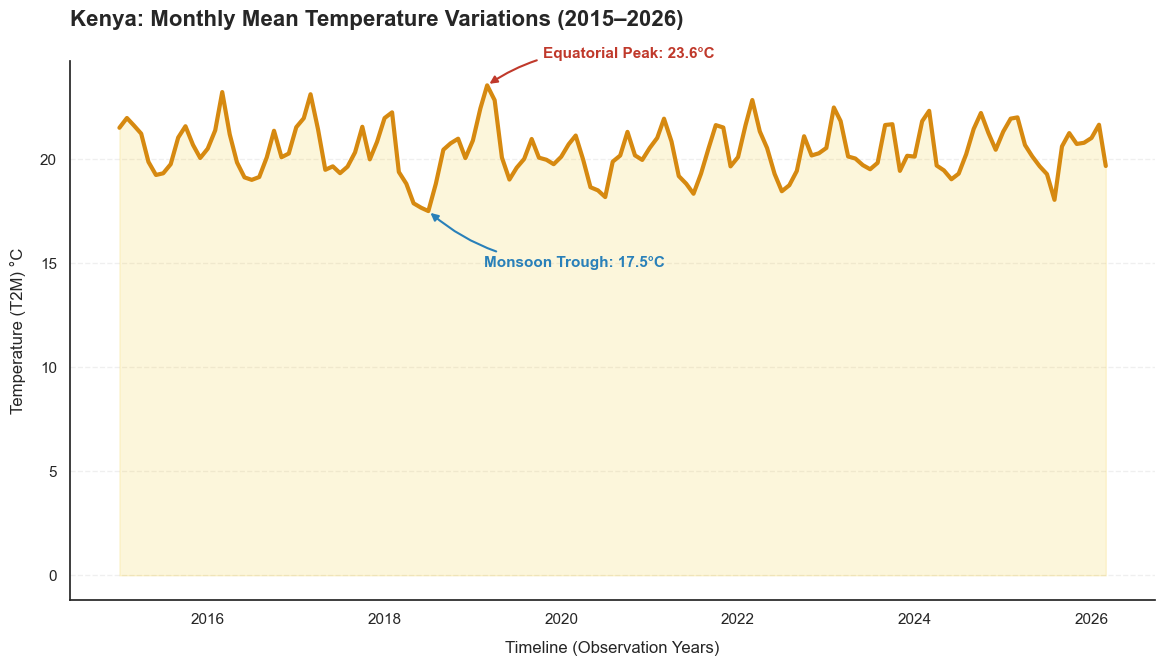

In [12]:
# Kenya: Specialized Monthly Temperature Profile (2015–2026)
plt.figure(figsize=(14, 7))

# 1. Use a clean white style and a "Savanna Gold" color palette
sns.set_style("white") 
line_color = '#d68910' # A warm, professional amber representing the Kenyan Savanna
fill_color = '#f1c40f' # A golden yellow for the area fill

# 2. Plot the line with professional thickness and area fill
ax = sns.lineplot(data=df_monthly, x='DATE', y='T2M', color=line_color, linewidth=3)
plt.fill_between(df_monthly['DATE'], df_monthly['T2M'], color=fill_color, alpha=0.15)

# 3. Premium Annotation: Equatorial Peak
plt.annotate(f'Equatorial Peak: {warmest_month["T2M"]:.1f}°C', 
             xy=(warmest_month['DATE'], warmest_month['T2M']),
             xytext=(40, 20), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#c0392b',
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=.2", color='#c0392b', lw=1.5))

# 4. Premium Annotation: Monsoon Trough
plt.annotate(f'Monsoon Trough: {coolest_month["T2M"]:.1f}°C', 
             xy=(coolest_month['DATE'], coolest_month['T2M']),
             xytext=(40, -40), textcoords='offset points',
             fontsize=11, fontweight='bold', color='#2980b9',
             arrowprops=dict(arrowstyle='-|>', connectionstyle="arc3,rad=-.2", color='#2980b9', lw=1.5))

# 5. Professional Aesthetic Polish
plt.title("Kenya: Monthly Mean Temperature Variations (2015–2026)", 
          fontsize=16, fontweight='bold', pad=25, loc='left')
plt.ylabel("Temperature (T2M) °C", fontsize=12, labelpad=10)
plt.xlabel("Timeline (Observation Years)", fontsize=12, labelpad=10)

# Add a subtle horizontal grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine() # Modern look by removing the top/right frame

plt.show()

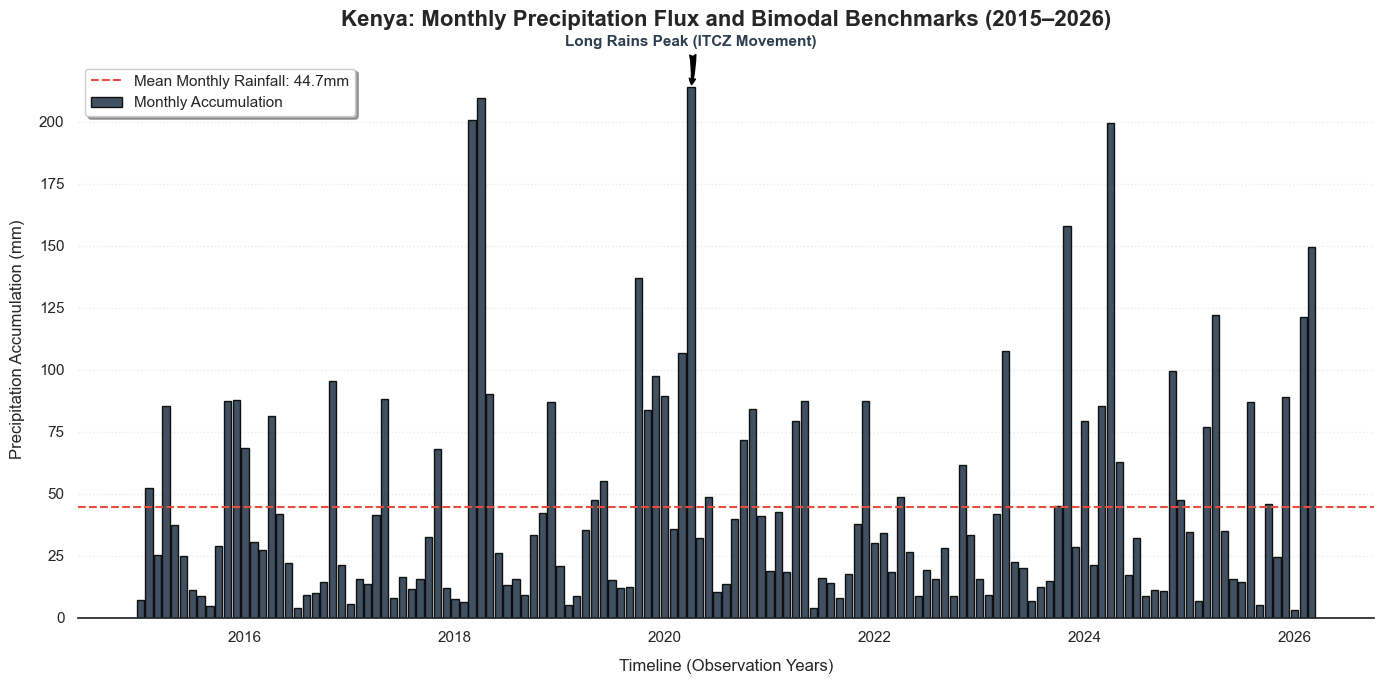

In [13]:
# Kenya: Specialized Monthly Precipitation Dynamics (2015–2026)
plt.figure(figsize=(14, 7))

# 1. Use a High-Contrast "Storm" Palette (Charcoal/Black)
bar_color = '#2c3e50' # A professional deep charcoal/black
edge_color = 'black'

# 2. Create the bar chart
plt.bar(df_monthly['DATE'], df_monthly['PRECTOTCORR'], 
        color=bar_color, edgecolor=edge_color, alpha=0.9, 
        width=25, label='Monthly Accumulation')

# 3. Add a horizontal line for the "Baseline" (Average Rainfall)
avg_rain = df_monthly['PRECTOTCORR'].mean()
plt.axhline(avg_rain, color='#e74c3c', linestyle='--', linewidth=1.5, 
            label=f'Mean Monthly Rainfall: {avg_rain:.1f}mm')

# 4. Professional Annotation: The Bimodal Peak
plt.annotate('Long Rains Peak (ITCZ Movement)', 
             xy=(peak_rain_month['DATE'], peak_rain_month['PRECTOTCORR']),
             xytext=(0, 30), 
             textcoords='offset points',
             ha='center', 
             fontsize=11,
             fontweight='bold', 
             color='#2c3e50',
             arrowprops=dict(arrowstyle='fancy', 
                             color="black", 
                             connectionstyle="arc3,rad=-0.1"))

# 5. Professional Aesthetic Polish
plt.title('Kenya: Monthly Precipitation Flux and Bimodal Benchmarks (2015–2026)', 
          fontsize=16, fontweight='bold', pad=25, loc='center')
plt.xlabel('Timeline (Observation Years)', fontsize=12, labelpad=10)
plt.ylabel('Precipitation Accumulation (mm)', fontsize=12, labelpad=10)

# Professional Grid: Subtle horizontal lines only
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend(frameon=True, shadow=True, loc='upper left')

# Clean up the frame (Despine)
sns.despine(left=True, bottom=False)

plt.tight_layout()
plt.show()

***
### 📊 Time Series Analysis: Thermal and Precipitation Trends (Kenya)

#### 1. Temperature Profile: Equatorial Consistency
The line chart illustrates the monthly mean temperature variations in Kenya over the full 2015–2026 period.
*   **Equatorial Stability:** Kenya exhibits a remarkably stable temperature baseline compared to northern study areas. The range between the **Equatorial Peak (23.6°C)** and the **Monsoon Trough (17.5°C)** is narrow, reflecting the country's position on the equator where solar radiation remains relatively constant.
*   **The Rift Valley Signature:** The mean temperature of ~20°C suggests the study area is located in the elevated plateaus or the Rift Valley region, where altitude moderates the intense heat found in sea-level equatorial zones.
*   **Observation:** The rhythmic "sawtooth" pattern shows a steady climatic pulse, with the coolest months typically occurring mid-year (June-July), coinciding with the Southern Hemisphere's winter influence.

#### 2. Precipitation Dynamics: The Bimodal Rhythm
The bar chart illustrates the monthly rainfall accumulation, revealing a distinct **Bimodal Signature**.
*   **The Twin Peaks:** Unlike the single monsoon patterns found further north, Kenya’s data shows two distinct rainy seasons annually: the **Long Rains** (March-May) and the **Short Rains** (October-December). This is a direct result of the Intertropical Convergence Zone (ITCZ) passing over the equator twice each year.
*   **The 2020 Anomaly:** A major climatic anomaly is visible in **early 2020**. During this period, the monthly rainfall surged to over **200mm**, which is nearly **five times** the mean monthly rainfall of **44.7mm**. This represents an extreme weather event likely linked to a strong Indian Ocean Dipole (IOD) phase, causing widespread flooding.
*   **Baseline Comparison:** The red dashed line (Mean: 44.7mm) highlights that while Kenya is often perceived as arid, its water supply is quite robust during peak years, though highly volatile between seasons.

#### 3. Synthesis: Climate Trends for COP32
By analyzing these trends, we can observe that while Kenya's temperature remains stable, its **precipitation intensity is highly unpredictable**. 
*   **Trend Insight:** The variance between the "Long Rains" and "Short Rains" appears to be increasing in the latter half of the decade (2020–2026). The massive 2020 spike followed by lower-than-average years (like 2021) illustrates a growing risk of rapid transitions between flood and drought, which is a primary focus for regional climate adaptation strategies.

***

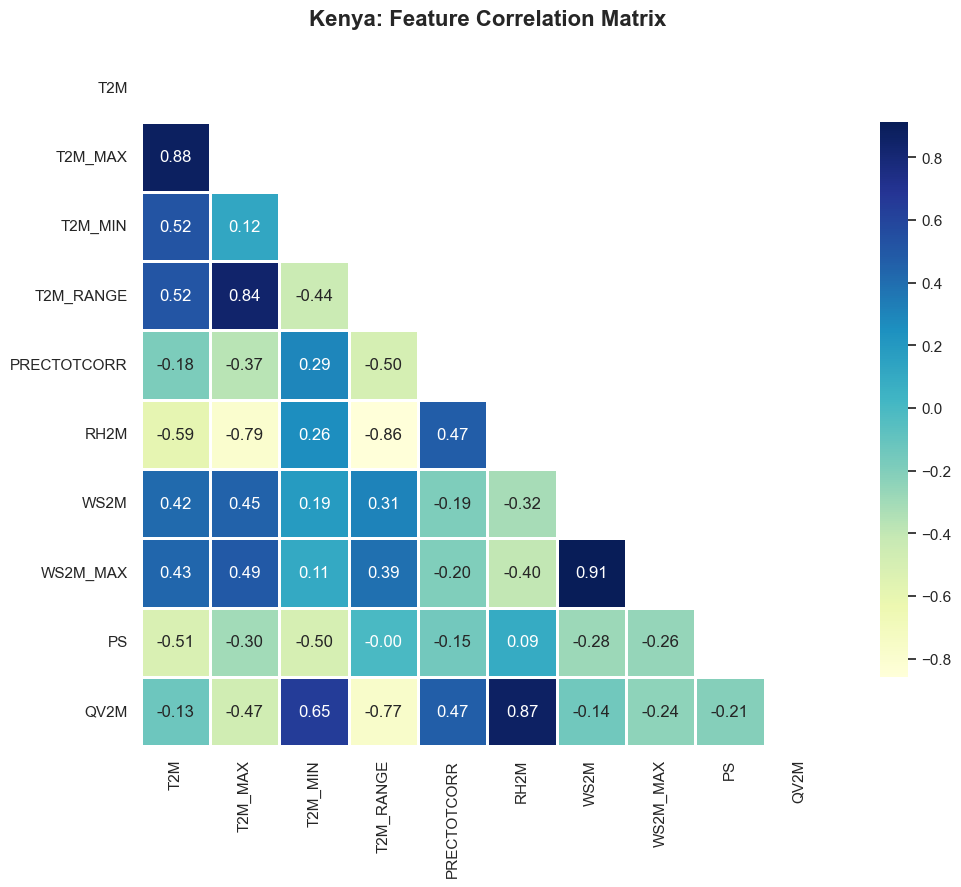

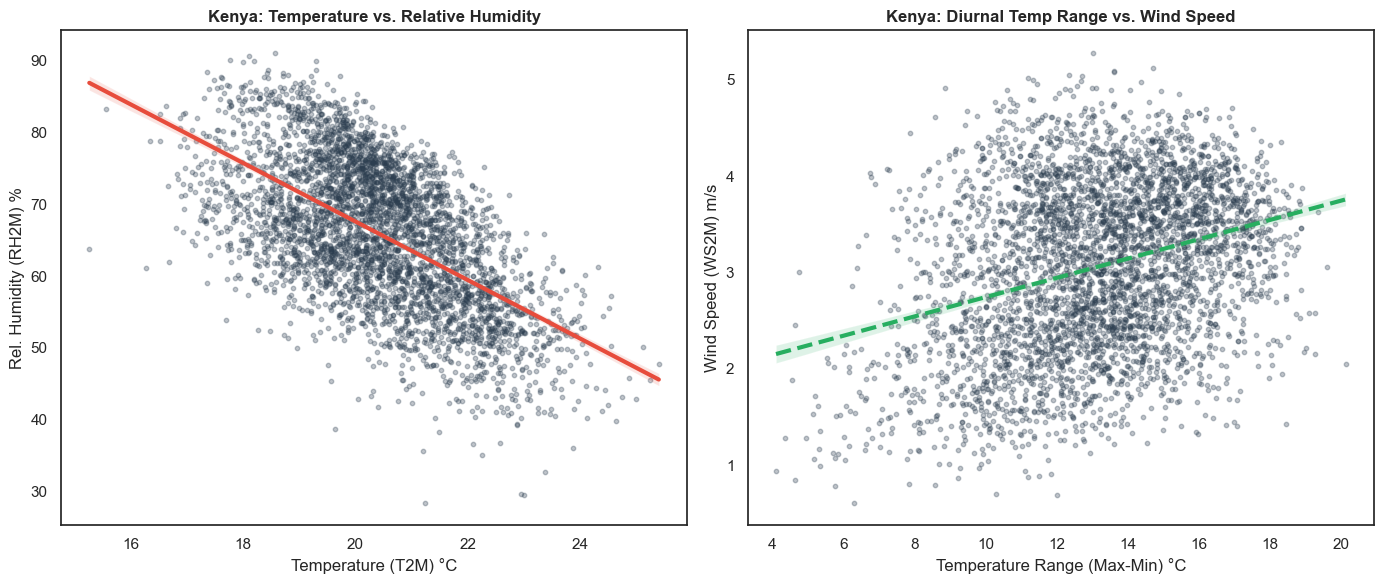

In [14]:
# --- 1. Setup Global Aesthetic (Consistent Professional Brand) ---
sns.set_theme(style="white", palette="muted")
plt.rcParams['font.family'] = 'sans-serif'

# Prep: Ensure Range exists and select numeric climate data
df['T2M_RANGE'] = df['T2M_MAX'] - df['T2M_MIN']
# Focus on core climate variables for a clean matrix
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
numeric_df = df[cols]

# --- 2. Kenya: Correlation Heatmap (YlGnBu Style) ---
plt.figure(figsize=(12, 9))

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, 
            mask=mask, 
            cmap='YlGnBu',     # Consistent premium look
            annot=True, 
            fmt=".2f", 
            linewidths=1,      
            cbar_kws={"shrink": .8}, 
            square=True)

plt.title("Kenya: Feature Correlation Matrix", fontsize=16, fontweight='bold', pad=20)
plt.show()

# --- 3. Kenya: Relationship Plots with Custom Styling ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Temp vs Humidity (Equatorial Buffer Plot)
sns.regplot(data=df, x='T2M', y='RH2M', ax=ax1, 
            scatter_kws={'alpha':0.3, 's':10, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'lw':3})
ax1.set_title("Kenya: Temperature vs. Relative Humidity", fontweight='bold')
ax1.set_xlabel("Temperature (T2M) °C")
ax1.set_ylabel("Rel. Humidity (RH2M) %")

# Plot 2: Temp Range vs Wind Speed (Rift Valley Dynamics)
sns.regplot(data=df, x='T2M_RANGE', y='WS2M', ax=ax2, 
            scatter_kws={'alpha':0.3, 's':10, 'color':'#2c3e50'}, 
            line_kws={'color':'#27ae60', 'lw':3, 'ls':'--'})
ax2.set_title("Kenya: Diurnal Temp Range vs. Wind Speed", fontweight='bold')
ax2.set_xlabel("Temperature Range (Max-Min) °C")
ax2.set_ylabel("Wind Speed (WS2M) m/s")

plt.tight_layout()
plt.show()

***
### 🔍 Correlation and Relationship Analysis: Kenya

#### 1. Identification of the Three Strongest Correlations
By analyzing the Feature Correlation Matrix for the Kenyan study area, the three strongest absolute relationships are:
1.  **WS2M and WS2M_MAX (r = 0.91):** A near-perfect positive correlation between sustained wind and peak gusts.
2.  **T2M and T2M_MAX (r = 0.88):** A very strong positive correlation between mean and maximum daily temperatures.
3.  **RH2M and QV2M (r = 0.87):** A strong positive link between Relative and Specific Humidity.
*   *Note: The strongest negative correlation is **RH2M and T2M_RANGE (r = -0.86)**.*

#### 2. Interpretation of Climatic Relationships
*   **The Atmospheric Consistency (0.91):** The extremely high correlation between `WS2M` and `WS2M_MAX` indicates that Kenya’s wind patterns are relatively steady. When the baseline wind speed increases, peak gusts increase in lockstep. This suggests a lack of erratic, turbulent shielding in the region, characteristic of open savanna or plateau landscapes.
*   **The Thermal Blanket Effect (RH2M vs. T2M_RANGE, -0.86):** This is the most critical climatic insight in the dataset. The powerful negative correlation between moisture (Humidity) and the diurnal temperature range shows that **moisture acts as a thermal regulator.** In Kenya, high humidity "traps" heat, keeping day and night temperatures close together. When the air dries out (low humidity), the "blanket" is removed, leading to much hotter days and cooler nights.
*   **Temperature vs. Humidity (Scatter Plot 1):** The regression plot of `T2M` vs. `RH2M` shows a sharp negative slope. This illustrates the **Equatorial Buffer**: as the temperature rises, the air's relative capacity to hold moisture increases, causing the relative humidity percentage to drop significantly. This is a classic signature of the dry savanna seasons.
*   **Wind and Temperature Swing (Scatter Plot 2):** The positive trend (green dashed line) between `T2M_RANGE` and `WS2M` indicates that larger daily temperature swings are associated with higher wind speeds. This is likely due to **convective mixing**; as the sun heats the ground and creates a large temperature range, it generates pressure differences that drive higher wind velocities across the plains.
***

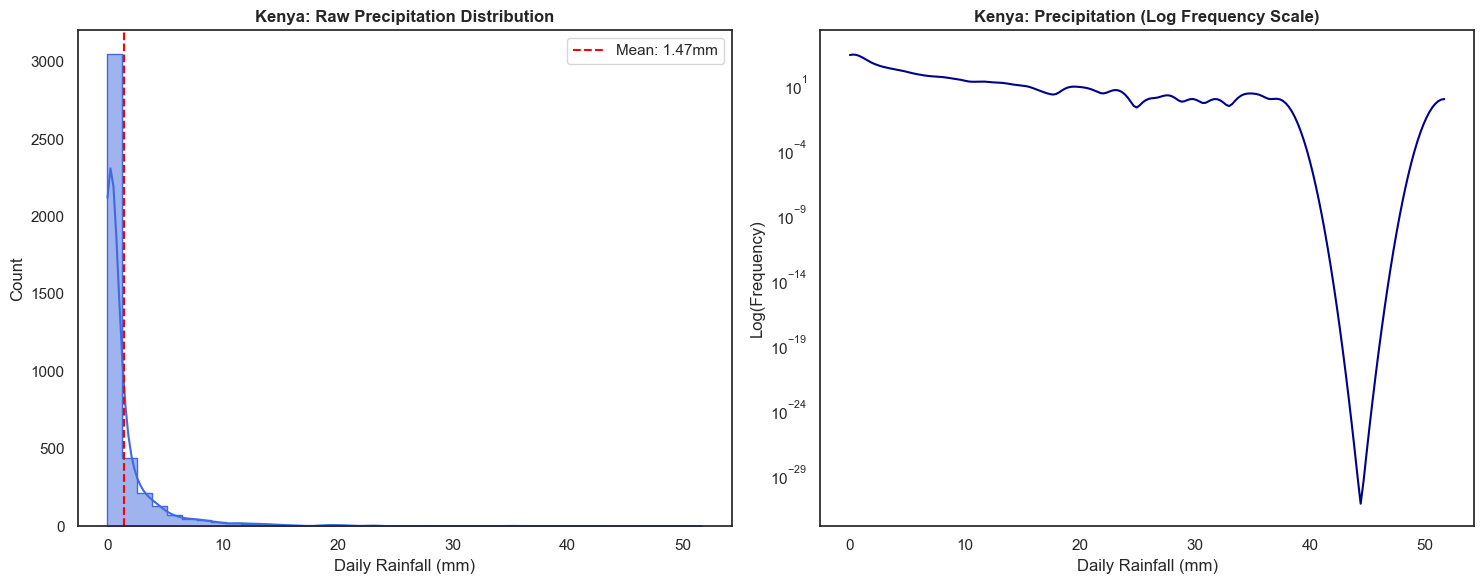

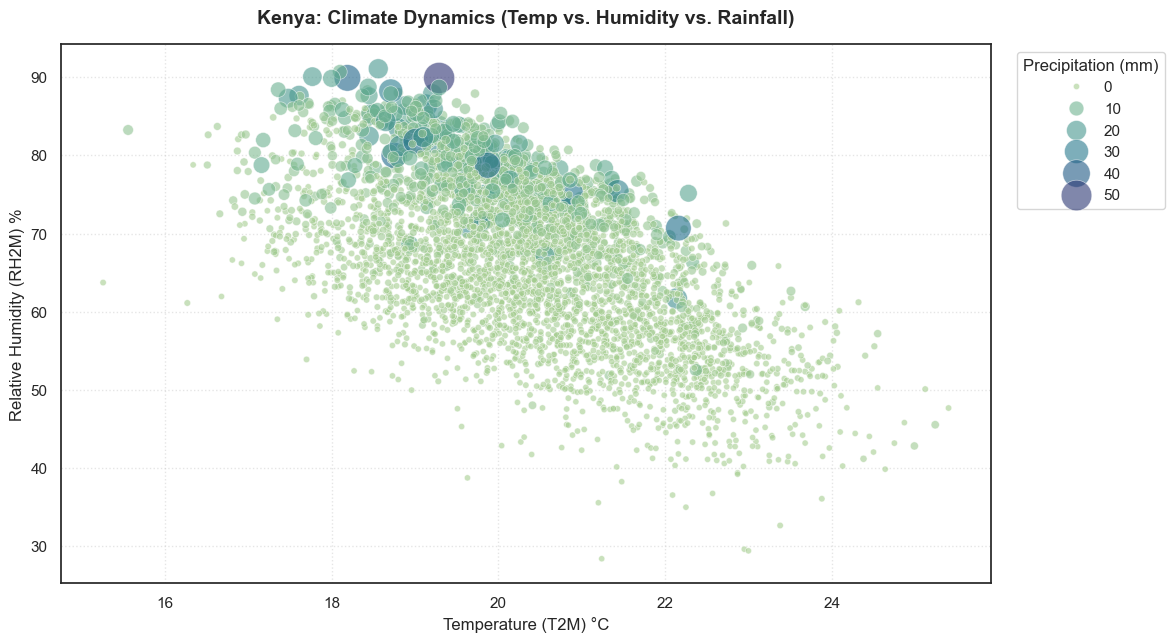

In [16]:
# Rainfall Distribution & Climate Dynamics (Kenya)
# 1. Compare Raw vs. Log Transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Raw Distribution with Statistical Mean Line
# Using royalblue to represent the reliable equatorial rains
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, ax=ax1, color='royalblue', element="step")
ax1.axvline(df['PRECTOTCORR'].mean(), color='red', linestyle='--', label=f'Mean: {df["PRECTOTCORR"].mean():.2f}mm')
ax1.set_title("Kenya: Raw Precipitation Distribution", fontweight='bold')
ax1.set_xlabel("Daily Rainfall (mm)")
ax1.legend()

# Plot 2: Log Scale (Identifying the "Bimodal" Storm Frequency)
sns.histplot(df['PRECTOTCORR'], bins=40, kde=True, ax=ax2, color='darkblue', log_scale=(False, True))
ax2.set_title("Kenya: Precipitation (Log Frequency Scale)", fontweight='bold')
ax2.set_xlabel("Daily Rainfall (mm)")
ax2.set_ylabel("Log(Frequency)")

plt.tight_layout()
plt.show()

# --- Plot 2: Advanced Bubble Chart (Multivariate Equatorial Analysis) ---
plt.figure(figsize=(12, 7))

# Using the 'crest' palette to maintain your project's high-end brand
scatter = sns.scatterplot(data=df, x='T2M', y='RH2M', 
                         size='PRECTOTCORR', hue='PRECTOTCORR',
                         palette='crest', sizes=(20, 500), 
                         alpha=0.6, edgecolor='white', linewidth=0.5)

plt.title("Kenya: Climate Dynamics (Temp vs. Humidity vs. Rainfall)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Temperature (T2M) °C")
plt.ylabel("Relative Humidity (RH2M) %")

# Legend cleanup for a professional finish
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Precipitation (mm)", frameon=True)
plt.grid(True, linestyle=':', alpha=0.5)

plt.show()


### 🌧️ Distribution Analysis: Precipitation and Multivariate Dynamics

#### 1. Precipitation Distribution (Histogram Analysis)
*   **Distribution Shape:** The raw precipitation histogram reveals an **extremely right-skewed** distribution. The vast majority of daily records show little to no rainfall (concentrated near 0), while the "tail" extends toward the 50mm+ range. 
*   **Log-Scale Insights:** Because the mean rainfall is quite low (**1.47mm**), the raw chart hides the intensity of storm events. By applying a **log-frequency scale** (right chart), we can see that while intense rainfall (40mm - 50mm) is statistically rare, it follows a distinct stochastic pattern. These "heavy tail" events represent the vital monsoon pulses that sustain the Kenyan ecosystem.
*   **Interpretation:** The low daily mean is a poor indicator of climatic risk; the distribution proves that Kenya’s water supply is dominated by infrequent, high-intensity pulses rather than steady daily accumulation.

#### 2. Multivariate Climate Dynamics (Bubble Chart)
The bubble chart visualizes the complex interaction between **Temperature (T2M)**, **Relative Humidity (RH2M)**, and **Precipitation (Bubble Size)**.
*   **The "Savanna Rain Window":** Significant rainfall events (the largest, dark bubbles) are not randomly occurring. They are tightly clustered in a specific "Trigger Window" where **Relative Humidity is above 80%** and **Temperature is between 18°C and 20°C**.
*   **Moisture Threshold:** There is a visible "humidity floor" around 75%; below this level, even at optimal temperatures, significant rainfall (bubbles) is almost non-existent. This confirms that humidity is the primary driver of precipitation in the Kenyan study area.
*   **Equatorial Dynamics:** Notice that as temperatures climb toward 24°C+, the bubbles disappear. In the Kenyan savanna context, extreme heat often correlates with dry, stable air, while the "cooler" phases of the year align with the humid, rain-bearing ITCZ movement.

***

References & Self-Learning
During this analysis, the following resources were consulted to ensure best practices in climate data handling:
1. **NASA POWER Documentation:** Understood the -999 sentinel value and parameter definitions (T2M, PRECTOTCORR).
2. **Seaborn Documentation:** Utilized the `regplot` and `heatmap` masking techniques for clearer visualization.
3. **Scipy Stats:** Implemented `zscore` for statistical outlier detection.
4. **Python Pathlib:** Implemented for cross-platform file management and robust export paths.